# Figure 10 — Comparison of different loading modes

This notebook compares the homogenized permeability response under uniaxial stretch, volumetric deformation, simple shear, and gas-pressure loading for several porous microstructures.

---

**Authors**

Haotian XIAO
Martin GENET

École Polytechnique, Palaiseau, France

## Imports

In [1]:
from pathlib import Path
import math
import sys

import dolfin
import myPythonLibrary as mypy
import dolfin_mech as dmech

## Project paths

In [2]:
def find_project_dir():
    current_dir = Path.cwd().resolve()

    for candidate in (current_dir, *current_dir.parents):
        if (
            (candidate / "demos").is_dir()
            and (candidate / "src").is_dir()
            and (candidate / "environment.yml").is_file()
        ):
            return candidate

    raise RuntimeError("Could not locate the project directory.")


PROJECT_DIR = find_project_dir()
SRC_DIR = PROJECT_DIR / "src"
RESULTS_DIR = PROJECT_DIR / "results"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

print("PROJECT_DIR =", PROJECT_DIR)
print("SRC_DIR =", SRC_DIR)
print("RESULTS_DIR =", RESULTS_DIR)

PROJECT_DIR = /Users/xiao/PhD/Project_MicroPoroFlow
SRC_DIR = /Users/xiao/PhD/Project_MicroPoroFlow/src
RESULTS_DIR = /Users/xiao/PhD/Project_MicroPoroFlow/results


## Loading functions

In [3]:
def run_figure10_loading_cases(
    res_folder,
    r0_list=(0.072, 0.41, 0.5),
    mode_list=(
        "stretch_x",
        "volumic",
        "simple_shear",
        "gas_pressure",
    ),
    probe_list=("gx", "gy"),
    pg=0.5,
    Umax=0.3,
    beta=0.3,
    perform_tests=0,
):
    res_folder = Path(res_folder)
    res_folder.mkdir(parents=True, exist_ok=True)

    test = mypy.Test(
        res_folder=str(res_folder),
        perform_tests=perform_tests,
        stop_at_failure=1,
        clean_after_tests=0,
        tester_numpy_tolerance=1e-2,
    )

    material_parameters = {
        "alpha": 0.16,
        "gamma": 0.5,
        "c1": 0.2,
        "c2": 0.4,
        "kappa": 1.0,
        "eta": 1e-5,
    }

    dim = 2
    n_steps = 2
    bcs = "pbc"

    valid_modes = (
        "stretch_x",
        "volumic",
        "simple_shear",
        "gas_pressure",
    )
    valid_probes = ("gx", "gy")

    for mode in mode_list:
        if mode not in valid_modes:
            raise ValueError(
                "mode must be 'stretch_x', 'volumic', "
                "'simple_shear', or 'gas_pressure'"
            )

    for probe in probe_list:
        if probe not in valid_probes:
            raise ValueError("probe must be 'gx' or 'gy'")

    def format_float_for_filename(value):
        return f"{value:.6g}"

    def make_solid_loading(mode):
        solid_loading = {}

        if mode == "stretch_x":
            solid_loading["U_bar_00_lst"] = [
                0.0,
                Umax,
            ]

        elif mode == "volumic":
            solid_loading["U_bar_00_lst"] = [
                0.0,
                Umax,
            ]
            solid_loading["U_bar_11_lst"] = [
                0.0,
                Umax,
            ]

        elif mode == "simple_shear":
            solid_loading["U_bar_00_lst"] = [0.0, 0.0]
            solid_loading["U_bar_01_lst"] = [
                0.0,
                beta,
            ]
            solid_loading["U_bar_10_lst"] = [0.0, 0.0]
            solid_loading["U_bar_11_lst"] = [0.0, 0.0]

        elif mode == "gas_pressure":
            solid_loading["U_bar_00_lst"] = [0.0, 0.0]
            solid_loading["U_bar_01_lst"] = [0.0, 0.0]
            solid_loading["U_bar_10_lst"] = [0.0, 0.0]
            solid_loading["U_bar_11_lst"] = [0.0, 0.0]

        return solid_loading

    def run_one_probe(
        r0,
        probe,
        mode,
    ):
        if probe == "gx":
            gx_ini_lst = [0.0, 0.01]
            gx_fin_lst = [0.01, 0.01]
            gy_ini_lst = [0.0, 0.0]
            gy_fin_lst = [0.0, 0.0]

        elif probe == "gy":
            gx_ini_lst = [0.0, 0.0]
            gx_fin_lst = [0.0, 0.0]
            gy_ini_lst = [0.0, 0.01]
            gy_fin_lst = [0.01, 0.01]

        if mode == "gas_pressure":
            pg_lst = [0.0, pg]
            pg_tag = pg
        else:
            pg_lst = [0.0, 0.0]
            pg_tag = 0.0

        r0_str = format_float_for_filename(r0)
        pg_str = format_float_for_filename(pg_tag)

        res_basename = (
            f"Fig10-{mode}-r0={r0_str}"
            f"-pf={pg_str}-{probe}"
        )

        result_basename = res_folder / res_basename
        mesh_filebasename = (
            res_folder
            / f"mesh-{mode}-r0={r0_str}-{probe}"
        )

        load_params = {
            "solid": {},
            "liquid": {},
            "air": {},
        }

        for i in range(dim):
            for j in range(dim):
                load_params["solid"][f"sigma_bar_{i}{j}"] = 0.0

        solid_loading = make_solid_loading(mode)

        for key, value in solid_loading.items():
            load_params["solid"][key] = value

        load_params["liquid"]["pl_bar_ini_lst"] = [0.0] * n_steps
        load_params["liquid"]["pl_bar_fin_lst"] = [0.0] * n_steps

        load_params["liquid"]["grad_p_bar_x_ini_lst"] = gx_ini_lst
        load_params["liquid"]["grad_p_bar_x_fin_lst"] = gx_fin_lst
        load_params["liquid"]["grad_p_bar_y_ini_lst"] = gy_ini_lst
        load_params["liquid"]["grad_p_bar_y_fin_lst"] = gy_fin_lst

        load_params["liquid"]["Theta_in_ini_lst"] = [0.0] * n_steps
        load_params["liquid"]["Theta_in_fin_lst"] = [0.0] * n_steps
        load_params["liquid"]["Theta_out_ini_lst"] = [0.0] * n_steps
        load_params["liquid"]["Theta_out_fin_lst"] = [0.0] * n_steps

        load_params["air"]["pf"] = pg_tag
        load_params["air"]["pf_lst"] = pg_lst

        dmech.run_HollowBox_MicroPoroflow(
            dim=dim,
            mesh_params={
                "dim": dim,
                "xmin": 0.0,
                "ymin": -math.sqrt(3.0) / 2.0,
                "xmax": 1.0,
                "ymax": math.sqrt(3.0) / 2.0,
                "r0": r0,
                "l": 0.03,
                "hole_shape": "hex",
                "add_center_hole": True,
                "mesh_filebasename": str(mesh_filebasename),
            },
            mat_params={
                "skel": {
                    "parameters": material_parameters,
                    "scaling": "no",
                },
                "bulk": {
                    "parameters": material_parameters,
                    "scaling": "no",
                },
                "pore": {
                    "parameters": material_parameters,
                    "scaling": "no",
                },
            },
            flow_params={
                "k_l": dolfin.Constant(
                    (
                        (1e-6, 0.0),
                        (0.0, 1e-6),
                    )
                ),
                "use_kozeny_carman": False,
            },
            porosity_params={
                "type": "constant",
                "val": 0.3,
            },
            bcs=bcs,
            step_params={
                "n_steps": n_steps,
                "Deltat_lst": [1e-2, 1e-1],
                "dt_ini_lst": [1e-3, 1e-3],
                "dt_min_lst": [1e-4, 1e-4],
                "dt_max_lst": [5e-3, 5e-3],
            },
            load_params=load_params,
            res_basename=str(result_basename),
            verbose=0,
        )

        return result_basename

    print("res_folder =", res_folder)
    print("r0_list =", r0_list)
    print("mode_list =", mode_list)
    print("probe_list =", probe_list)
    print("pg =", pg)
    print("Umax =", Umax)
    print("beta =", beta)

    for mode in mode_list:
        for r0 in r0_list:
            for probe in probe_list:
                print()
                print("========================================")
                print(
                    f"Running mode={mode}, "
                    f"r0={r0}, pg={pg}, probe={probe}"
                )
                print("========================================")

                result_basename = run_one_probe(
                    r0=r0,
                    probe=probe,
                    mode=mode,
                )

                test.test(str(result_basename))

    return res_folder


## Simulation parameters

In [4]:
r0_list = (
    0.07,
    0.10,
    0.15,
    0.20,
    0.25,
    0.30,
    0.35,
    0.41,
    0.45,
)

mode_list = (
    "stretch_x",
    "volumic",
    "simple_shear",
    "gas_pressure",
)

probe_list = ("gx", "gy")

pg = 0.5
Umax = 0.3
beta = 0.3

res_folder = RESULTS_DIR / "Figure10_loading_comparison"

## Numerical simulations

In [5]:
res_folder = run_figure10_loading_cases(
    res_folder=res_folder,
    r0_list=r0_list,
    mode_list=mode_list,
    probe_list=probe_list,
    pg=pg,
    Umax=Umax,
    beta=beta,
    perform_tests=0,
)

print("Results saved in:", res_folder)


res_folder = /Users/xiao/PhD/Project_MicroPoroFlow/results/Figure10_loading_comparison
r0_list = (0.07, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.41, 0.45)
mode_list = ('stretch_x', 'volumic', 'simple_shear', 'gas_pressure')
probe_list = ('gx', 'gy')
pg = 0.5
Umax = 0.3
beta = 0.3

Running mode=stretch_x, r0=0.07, pg=0.5, probe=gx
Info    : Reconstructing periodicity for curve connection 6 - 12                                             
Info    : Reconstructing periodicity for curve connection 9 - 3
Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 10%] Meshing curve 2 (Line)
Info    : [ 20%] Meshing curve 3 (Line)
Info    : [ 20%] Meshing curve 4 (Line)
Info    : [ 30%] Meshing curve 5 (Line)
Info    : [ 40%] Meshing curve 7 (Line)
Info    : [ 40%] Meshing curve 8 (Line)
Info    : [ 50%] Meshing curve 9 (Line) as a copy of curve 3
Info    : [ 60%] Meshing curve 10 (Line)
Info    : [ 60%] Meshing curve 11 (Line)
Info    : [ 70%] Meshing curve 12 (Line)
Info    : [ 

/opt/anaconda3/envs/dolfin-clean/lib/python3.10/site-packages/ufl/exproperators.py:336: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  if arg in ("+", "-"):



Running mode=stretch_x, r0=0.07, pg=0.5, probe=gy
Info    : Reconstructing periodicity for curve connection 6 - 12                                             
Info    : Reconstructing periodicity for curve connection 9 - 3
Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 10%] Meshing curve 2 (Line)
Info    : [ 20%] Meshing curve 3 (Line)
Info    : [ 20%] Meshing curve 4 (Line)
Info    : [ 30%] Meshing curve 5 (Line)
Info    : [ 40%] Meshing curve 7 (Line)
Info    : [ 40%] Meshing curve 8 (Line)
Info    : [ 50%] Meshing curve 9 (Line) as a copy of curve 3
Info    : [ 60%] Meshing curve 10 (Line)
Info    : [ 60%] Meshing curve 11 (Line)
Info    : [ 70%] Meshing curve 12 (Line)
Info    : [ 70%] Meshing curve 13 (Line)
Info    : [ 80%] Meshing curve 14 (Line)
Info    : [ 80%] Meshing curve 15 (Line)
Info    : [ 90%] Meshing curve 16 (Line)
Info    : [ 90%] Meshing curve 17 (Line)
Info    : [100%] Meshing curve 18 (Line)
Info    : [100%] Meshing curve 6 (Line) a

/opt/anaconda3/envs/dolfin-clean/lib/python3.10/site-packages/ufl/exproperators.py:336: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  if arg in ("+", "-"):



Running mode=stretch_x, r0=0.15, pg=0.5, probe=gy
Info    : Reconstructing periodicity for curve connection 6 - 12                                             
Info    : Reconstructing periodicity for curve connection 9 - 3
Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 10%] Meshing curve 2 (Line)
Info    : [ 20%] Meshing curve 3 (Line)
Info    : [ 20%] Meshing curve 4 (Line)
Info    : [ 30%] Meshing curve 5 (Line)
Info    : [ 40%] Meshing curve 7 (Line)
Info    : [ 40%] Meshing curve 8 (Line)
Info    : [ 50%] Meshing curve 9 (Line) as a copy of curve 3
Info    : [ 60%] Meshing curve 10 (Line)
Info    : [ 60%] Meshing curve 11 (Line)
Info    : [ 70%] Meshing curve 12 (Line)
Info    : [ 70%] Meshing curve 13 (Line)
Info    : [ 80%] Meshing curve 14 (Line)
Info    : [ 80%] Meshing curve 15 (Line)
Info    : [ 90%] Meshing curve 16 (Line)
Info    : [ 90%] Meshing curve 17 (Line)
Info    : [100%] Meshing curve 18 (Line)
Info    : [100%] Meshing curve 6 (Line) a

...


Running mode=simple_shear, r0=0.3, pg=0.5, probe=gy
Info    : Reconstructing periodicity for curve connection 6 - 12                                             
Info    : Reconstructing periodicity for curve connection 9 - 3
Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 10%] Meshing curve 2 (Line)
Info    : [ 20%] Meshing curve 3 (Line)
Info    : [ 20%] Meshing curve 4 (Line)
Info    : [ 30%] Meshing curve 5 (Line)
Info    : [ 40%] Meshing curve 7 (Line)
Info    : [ 40%] Meshing curve 8 (Line)
Info    : [ 50%] Meshing curve 9 (Line) as a copy of curve 3
Info    : [ 60%] Meshing curve 10 (Line)
Info    : [ 60%] Meshing curve 11 (Line)
Info    : [ 70%] Meshing curve 12 (Line)
Info    : [ 70%] Meshing curve 13 (Line)
Info    : [ 80%] Meshing curve 14 (Line)
Info    : [ 80%] Meshing curve 15 (Line)
Info    : [ 90%] Meshing curve 16 (Line)
Info    : [ 90%] Meshing curve 17 (Line)
Info    : [100%] Meshing curve 18 (Line)
Info    : [100%] Meshing curve 6 (Line)

/opt/anaconda3/envs/dolfin-clean/lib/python3.10/site-packages/ufl/exproperators.py:336: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  if arg in ("+", "-"):



Running mode=simple_shear, r0=0.35, pg=0.5, probe=gy
Info    : Reconstructing periodicity for curve connection 6 - 12                                             
Info    : Reconstructing periodicity for curve connection 9 - 3
Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 10%] Meshing curve 2 (Line)
Info    : [ 20%] Meshing curve 3 (Line)
Info    : [ 20%] Meshing curve 4 (Line)
Info    : [ 30%] Meshing curve 5 (Line)
Info    : [ 40%] Meshing curve 7 (Line)
Info    : [ 40%] Meshing curve 8 (Line)
Info    : [ 50%] Meshing curve 9 (Line) as a copy of curve 3
Info    : [ 60%] Meshing curve 10 (Line)
Info    : [ 60%] Meshing curve 11 (Line)
Info    : [ 70%] Meshing curve 12 (Line)
Info    : [ 70%] Meshing curve 13 (Line)
Info    : [ 80%] Meshing curve 14 (Line)
Info    : [ 80%] Meshing curve 15 (Line)
Info    : [ 90%] Meshing curve 16 (Line)
Info    : [ 90%] Meshing curve 17 (Line)
Info    : [100%] Meshing curve 18 (Line)
Info    : [100%] Meshing curve 6 (Line

/opt/anaconda3/envs/dolfin-clean/lib/python3.10/site-packages/ufl/exproperators.py:336: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  if arg in ("+", "-"):



Running mode=simple_shear, r0=0.45, pg=0.5, probe=gy
Info    : Reconstructing periodicity for curve connection 6 - 12                                             
Info    : Reconstructing periodicity for curve connection 9 - 3
Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 10%] Meshing curve 2 (Line)
Info    : [ 20%] Meshing curve 3 (Line)
Info    : [ 20%] Meshing curve 4 (Line)
Info    : [ 30%] Meshing curve 5 (Line)
Info    : [ 40%] Meshing curve 7 (Line)
Info    : [ 40%] Meshing curve 8 (Line)
Info    : [ 50%] Meshing curve 9 (Line) as a copy of curve 3
Info    : [ 60%] Meshing curve 10 (Line)
Info    : [ 60%] Meshing curve 11 (Line)
Info    : [ 70%] Meshing curve 12 (Line)
Info    : [ 70%] Meshing curve 13 (Line)
Info    : [ 80%] Meshing curve 14 (Line)
Info    : [ 80%] Meshing curve 15 (Line)
Info    : [ 90%] Meshing curve 16 (Line)
Info    : [ 90%] Meshing curve 17 (Line)
Info    : [100%] Meshing curve 18 (Line)
Info    : [100%] Meshing curve 6 (Line

## Post-processing

[WARNING] Uyy differs between gx and gy for mode=stretch_x, r0=0.07
uniaxial loading, r0=0.07, phi=0.014700, C_K=1.056144, A_K=2.128078, E_K=0.032689
[WARNING] Uyy differs between gx and gy for mode=stretch_x, r0=0.1
uniaxial loading, r0=0.1, phi=0.030000, C_K=1.034164, A_K=2.051511, E_K=0.061228
[WARNING] Uyy differs between gx and gy for mode=stretch_x, r0=0.15
uniaxial loading, r0=0.15, phi=0.067500, C_K=0.990762, A_K=1.895014, E_K=0.123300
[WARNING] Uyy differs between gx and gy for mode=stretch_x, r0=0.2
uniaxial loading, r0=0.2, phi=0.120000, C_K=0.948059, A_K=1.732503, E_K=0.193266
[WARNING] Uyy differs between gx and gy for mode=stretch_x, r0=0.25
uniaxial loading, r0=0.25, phi=0.187500, C_K=0.913261, A_K=1.587666, E_K=0.259745
[WARNING] Uyy differs between gx and gy for mode=stretch_x, r0=0.3
[WARNING] Uxy differs between gx and gy for mode=stretch_x, r0=0.3
[WARNING] Uyx differs between gx and gy for mode=stretch_x, r0=0.3
uniaxial loading, r0=0.3, phi=0.270000, C_K=0.888269,

2026-06-26 11:32:09.949 (3386.529s) [          815B1E]     vtkGenericCell.cxx:439    ERR| vtkGenericCell (0x168404080): Unsupported cell type: 51 Setting to vtkEmptyCell
2026-06-26 11:32:09.949 (3386.529s) [          815B1E]     vtkGenericCell.cxx:439    ERR| vtkGenericCell (0x168404080): Unsupported cell type: 52 Setting to vtkEmptyCell
2026-06-26 11:32:09.949 (3386.529s) [          815B1E]     vtkGenericCell.cxx:439    ERR| vtkGenericCell (0x168404080): Unsupported cell type: 53 Setting to vtkEmptyCell
2026-06-26 11:32:09.949 (3386.529s) [          815B1E]     vtkGenericCell.cxx:439    ERR| vtkGenericCell (0x168404080): Unsupported cell type: 54 Setting to vtkEmptyCell
2026-06-26 11:32:09.949 (3386.529s) [          815B1E]     vtkGenericCell.cxx:439    ERR| vtkGenericCell (0x168404080): Unsupported cell type: 55 Setting to vtkEmptyCell
2026-06-26 11:32:09.949 (3386.529s) [          815B1E]     vtkGenericCell.cxx:439    ERR| vtkGenericCell (0x168404080): Unsupported cell type: 56 Sett

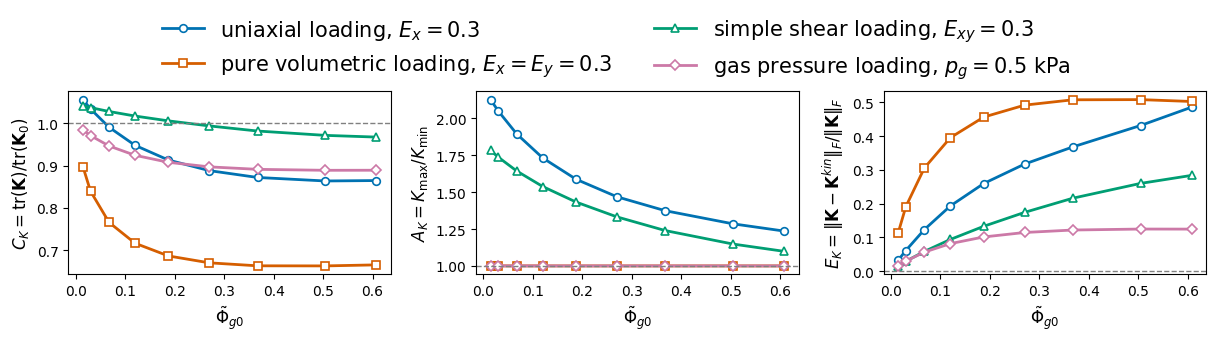

Saved: /Users/xiao/PhD/Project_MicroPoroFlow/results/figures/Figure10_loading_summary.pdf
Figure saved in: /Users/xiao/PhD/Project_MicroPoroFlow/results/figures/Figure10_loading_summary.pdf


In [6]:
from Plot_Microporoflow import plot_figure9_summary


figures_folder = RESULTS_DIR / "figures"
figures_folder.mkdir(parents=True, exist_ok=True)

figure_path = figures_folder / "Figure10_loading_summary.pdf"

rows = plot_figure9_summary(
    r0_list=r0_list,
    res_folder=str(res_folder),
    prefix="Fig10",
    pg=pg,
    save_name=str(figure_path),
    show_plot=True,
)

print("Figure saved in:", figure_path)